In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
##load auto MPG set
url= "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)
## display 5 rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
X = df[['displacement']]
y = df['mpg']
# check missing values

print("Missing values in:", X.isnull().sum())
print("Missing values in mpg:", y.isnull().sum())

Missing values in: displacement    0
dtype: int64
Missing values in mpg: 0


In [10]:
## remove rows containg missing values
data = df [['displacement' , 'mpg']].dropna()

X = df[['displacement']]
y = df['mpg']
## display the selected data
print("feature:")
print(X.head())

feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0


In [12]:
print("\n target:")
print(y.head())


 target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


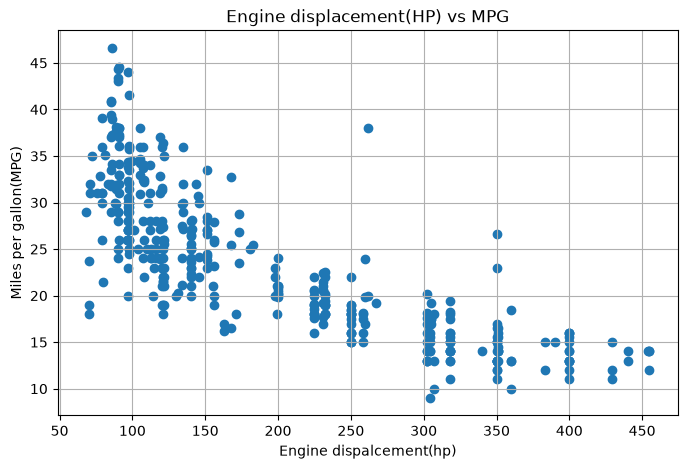

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(X,y)

plt.xlabel("Engine dispalcement(hp)")
plt.ylabel("Miles per gallon(MPG)")
plt.title("Engine displacement(HP) vs MPG")

plt.grid(True)
plt.show()

In [16]:
# split the dataset
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Traing Samples:",len(X_train))
print("Testing samples:",len(X_test))

Traing Samples: 318
Testing samples: 80


In [18]:
# create a linear regression model
linear_model = LinearRegression()
# train  the model
linear_model.fit(X_train,y_train)
#predict on test data
y_pred_linear = linear_model.predict(X_test)

In [20]:
#calculate MSE
mse_linear = mean_squared_error(y_test,y_pred_linear)
#calculate r-squared
r2_linear = r2_score(y_test,y_pred_linear)

print("Linear Regression results")
print("--------------------")
print("MSE:",mse_linear)
print("R-squared:", r2_linear)

Linear Regression results
--------------------
MSE: 18.102543998358946
R-squared: 0.6633114869465596


In [22]:
results =[]

                                                                #store polynomial models for plotting
polynomial_models={}

                                                                #add linear regression results
results.append({
    'Model':'Linear regression',
    'Degree' : 1,
    'MSE': mse_linear,
    'R_squared': r2_linear
})
                                                                #try polynomial degree from 2 to 5
for degree in range(2, 6):
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()

    poly_model.fit(X_train_poly, y_train)

    y_pred_poly = poly_model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    results.append({
        'Model': 'Polynomial regression',
        'Degree': degree,
        'MSE': mse,
        'R_squared': r2
    })

    polynomial_models[degree] = {
        'poly': poly,
        'model': poly_model
    }

In [23]:
#convert results into data frame
results_df = pd.DataFrame(results)
#Display results
results_df

,Model,Degree,MSE,R_squared
0,Linear regression,1,18.102544,0.663311
1,Polynomial regression,2,15.107354,0.719019
2,Polynomial regression,3,16.369649,0.695542
3,Polynomial regression,4,18.398790,0.657802
4,Polynomial regression,5,20.998146,0.609456


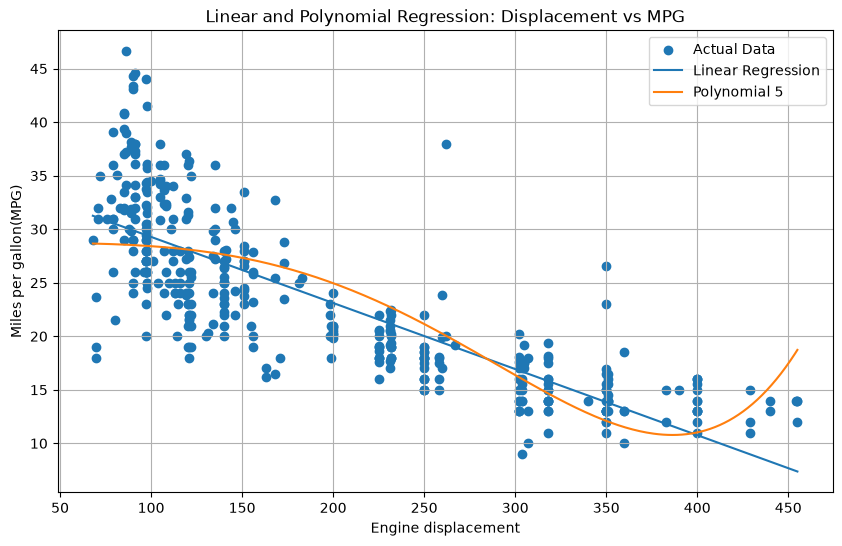

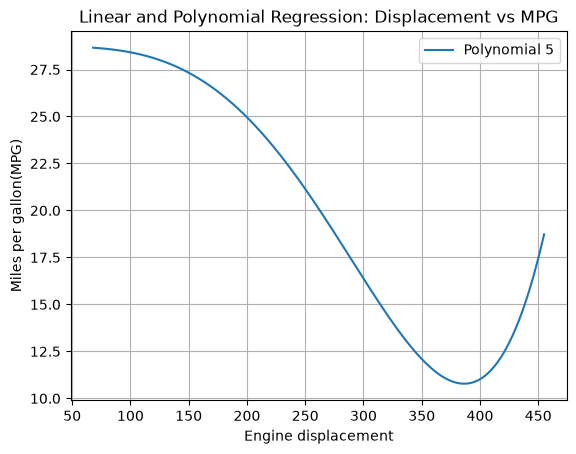

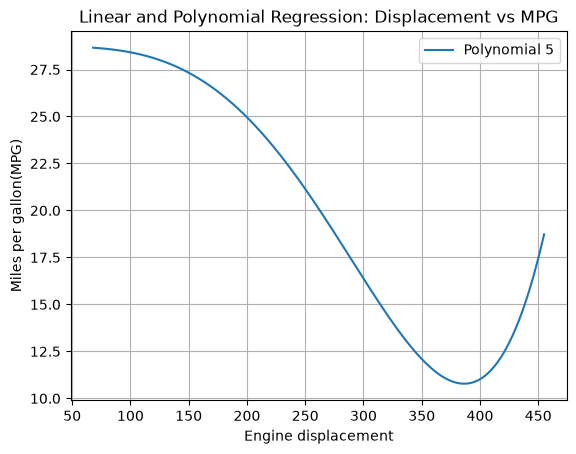

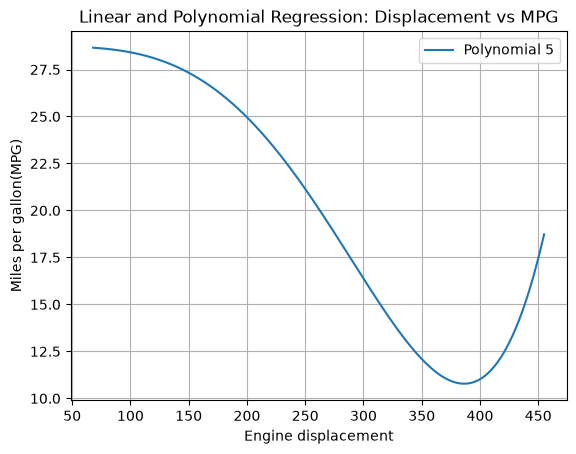

In [25]:
X_plot = pd.DataFrame({
    'displacement':np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),300)

})

plt.figure(figsize=(10,6))

plt.scatter(
    X['displacement'],y,label='Actual Data'
)

y_plot_linear = linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,label='Linear Regression'
)
for dergree in range(2,6):
    poly= polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    X_plot_poly=poly.transform(X_plot)
    y_plot_poly=poly_model.predict(X_plot_poly)

    plt.plot(
        X_plot['displacement'],y_plot_poly,label= f'Polynomial {degree}'
    )
    plt.xlabel('Engine displacement')
    plt.ylabel('Miles per gallon(MPG)')
    plt.title('Linear and Polynomial Regression: Displacement vs MPG'
             )
    plt.legend()
    plt.grid(True)
    plt.show()

Text(0.5, 1.0, 'Comparison of MSE')

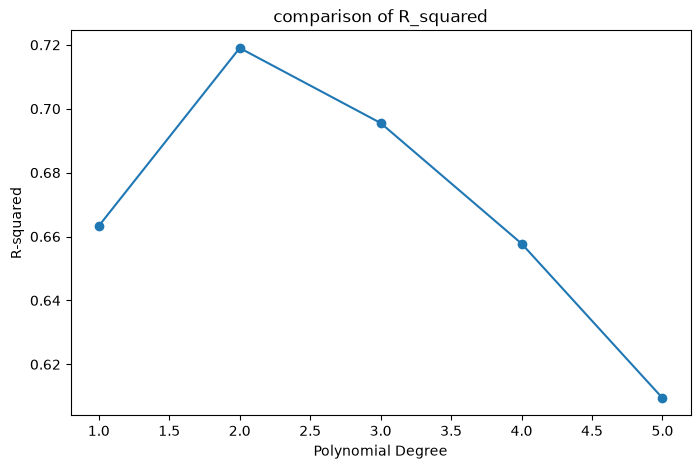

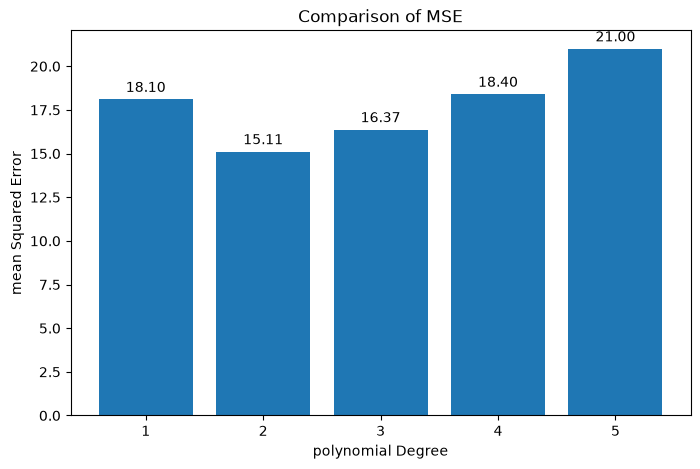

In [27]:
plt.figure(figsize=(8,5))
plt.plot(
    results_df['Degree'],
    results_df['R_squared'],
    marker='o'
)
plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("comparison of R_squared")

plt.figure(figsize=(8,5))
bars= plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

plt.bar_label(bars,fmt='%.2f',padding=3)

plt.xlabel("polynomial Degree")
plt.ylabel("mean Squared Error")
plt.title("Comparison of MSE")